In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["prix"] = data.target

print(df.head())
print(df.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude   prix  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
(20640, 9)


In [3]:
print(df.describe())
print(df.isnull().sum())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude          prix  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [4]:
#préparer les données pour le modèle
from sklearn.model_selection import train_test_split

# Séparer features (X) et target (y)
X = df.drop(columns=["prix"])
y = df["prix"]

# Découper en train (80%) et test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [5]:
#entraîner un modèle la régression linéaire — le modèle le plus simple
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Créer le modèle
model = LinearRegression()

# 2. Entraîner
model.fit(X_train, y_train)

# 3. Prédire
y_pred = model.predict(X_test)

# 4. Évaluer
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.2f}")

RMSE : 0.75
R² : 0.58


In [18]:
# un modèle plus puissant — la Random Forest 
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE : {rmse_rf:.2f}")
print(f"R² : {r2_rf:.2f}")

RMSE : 0.51
R² : 0.81


      feature  importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


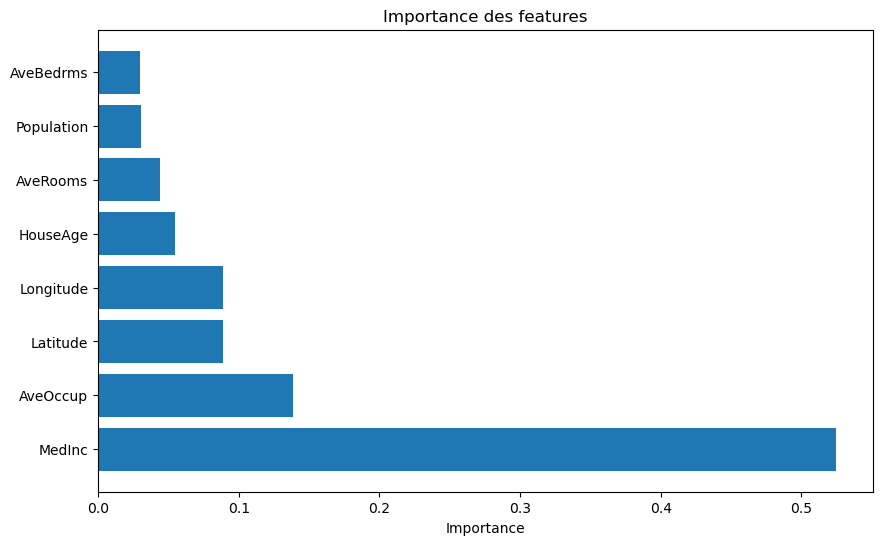

In [7]:

#Feature importance 
import pandas as pd
import matplotlib.pyplot as plt

# Récupérer l'importance des features
importances = model_rf.feature_importances_
features = X.columns

# Créer un DataFrame pour afficher proprement
df_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

print(df_importance)

# Visualiser
plt.figure(figsize=(10, 6))
plt.barh(df_importance["feature"], df_importance["importance"])
plt.title("Importance des features")
plt.xlabel("Importance")
plt.show()

In [8]:
# La normalisation des données sur RForest
from sklearn.preprocessing import StandardScaler

# Créer le scaler
scaler = StandardScaler()

# Normaliser X_train et X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Réentraîner la Random Forest sur les données normalisées
model_rf_scaled = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_rf_scaled.predict(X_test_scaled)

rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"RMSE : {rmse_scaled:.2f}")
print(f"R² : {r2_scaled:.2f}")

RMSE : 0.51
R² : 0.81


In [9]:
# La normalisation des données sur regression lineaire
model_lr_scaled = LinearRegression()
model_lr_scaled.fit(X_train_scaled, y_train)
y_pred_lr_scaled = model_lr_scaled.predict(X_test_scaled)

rmse_lr_scaled = np.sqrt(mean_squared_error(y_test, y_pred_lr_scaled))
r2_lr_scaled = r2_score(y_test, y_pred_lr_scaled)

print(f"RMSE : {rmse_lr_scaled:.2f}")
print(f"R² : {r2_lr_scaled:.2f}")

RMSE : 0.75
R² : 0.58


In [10]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [11]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"RMSE : {rmse_xgb:.2f}")
print(f"R² : {r2_xgb:.2f}")

RMSE : 0.46
R² : 0.84


In [12]:
#K-Nearest Neighbors sans normalisation
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print(f"RMSE sans normalisation : {rmse_knn:.2f}")
print(f"R² sans normalisation : {r2_knn:.2f}")

RMSE sans normalisation : 1.06
R² sans normalisation : 0.15


In [13]:
#K-Nearest Neighbors avec normalisation
model_knn_scaled = KNeighborsRegressor(n_neighbors=5)
model_knn_scaled.fit(X_train_scaled, y_train)
y_pred_knn_scaled = model_knn_scaled.predict(X_test_scaled)

rmse_knn_scaled = np.sqrt(mean_squared_error(y_test, y_pred_knn_scaled))
r2_knn_scaled = r2_score(y_test, y_pred_knn_scaled)

print(f"RMSE avec normalisation : {rmse_knn_scaled:.2f}")
print(f"R² avec normalisation : {r2_knn_scaled:.2f}")

RMSE avec normalisation : 0.66
R² avec normalisation : 0.67


In [16]:
from sklearn.model_selection import GridSearchCV

# Définir les paramètres à tester
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None]
}

# Créer le GridSearch
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,  # cross-validation à 5 plis
    scoring="r2"
)

grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur R² : {grid_search.best_score_:.2f}")

KeyboardInterrupt: 

In [17]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42),
    X, y, cv=5, scoring="r2"
)

print(f"Scores : {scores}")
print(f"Moyenne : {scores.mean():.2f}")
print(f"Écart-type : {scores.std():.2f}")

Scores : [0.51857219 0.70523043 0.74248174 0.63227819 0.68205721]
Moyenne : 0.66
Écart-type : 0.08


In [19]:
scores_xgb = cross_val_score(
    XGBRegressor(n_estimators=100, random_state=42),
    X, y, cv=5, scoring="r2"
)

print(f"Scores XGBoost : {scores_xgb}")
print(f"Moyenne : {scores_xgb.mean():.2f}")
print(f"Écart-type : {scores_xgb.std():.2f}")

Scores XGBoost : [0.54932537 0.70386605 0.72793222 0.66010998 0.64280305]
Moyenne : 0.66
Écart-type : 0.06
